# Target-Free Soft-Sensor Model Upgrades

This notebook improves the process-only virtual sensor without using current or historical `SLURRY_FREE_ACID` as an input.

The target remains the current quality value:

\[
X_{\le t}\longrightarrow \hat y_t.
\]

The notebook tests three focused hypotheses:

1. **Recency weighting:** recent training rows may better represent a drifting process.
2. **Clustered experts:** separate linear models may represent different operating regimes better than one global model.
3. **Linear/nonlinear blending:** Ridge and LightGBM may make complementary errors.

The original January test period has already been inspected in Notebook 05. It is therefore reported as a **retrospective benchmark**, not a new untouched test.


## 1. Configuration and reproducibility


### 1.1 Imports


In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json, time, warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")


### 1.2 Central configuration


In [2]:
RANDOM_STATE = 42
TARGET = "SLURRY_FREE_ACID"
TIME_COL = "Date"
FEATURE_SET = "D_full"
N_VALIDATION_BLOCKS = 4

PREPARATION_NOTEBOOK = Path("02_feature_engineering_data_preparation.ipynb")
PRIOR_RESULTS = Path("../reports/exogenous_virtual_sensor_artifacts/full_comparison.csv")
OUTPUT_DIR = Path("../reports/target_free_upgrade_artifacts")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for path in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)


### 1.3 Research basis and scope


Recent industrial soft-sensor research emphasizes local or just-in-time models, dynamic latent structures, adaptation to concept drift, and uncertainty under distribution shift. With only one month of labeled data, this notebook uses compact tests rather than deep sequence models:

- recency-weighted regression approximates gradual adaptation;
- clustered experts approximate multimodal/local soft sensing at manageable cost;
- validation-stable blending tests complementary linear and nonlinear errors;
- expanding chronological validation evaluates stability through time.

Deep TCN/RNN models are deferred until additional months show that compact models leave a consistent, practically important error gap.


## 2. Recover the frozen feature-preparation foundation


### 2.1 Replay Notebook 02 without changing its methodology


In [3]:
def recover_prepared_namespace(path):
    notebook = json.loads(path.read_text(encoding="utf-8"))
    namespace = {"display": lambda value: None}
    executed = 0
    with redirect_stdout(StringIO()):
        for cell in notebook["cells"]:
            if cell.get("cell_type") != "code":
                continue
            source = cell.get("source", "")
            source = "".join(source) if isinstance(source, list) else source
            if source.strip().startswith("import matplotlib.pyplot as plt"):
                break
            exec(compile(source, f"preparation_cell_{executed}", "exec"), namespace)
            executed += 1
    return namespace, executed

prep, replayed_cells = recover_prepared_namespace(PREPARATION_NOTEBOOK)
prepared = prep["prepared"]
raw_df = prep["df"].sort_values(prep["TIME_COL"]).reset_index(drop=True)
TARGET, TIME_COL = prep["TARGET"], prep["TIME_COL"]
print(f"Recovered the preparation foundation from {replayed_cells} code cells.")


Recovered the preparation foundation from 37 code cells.


### 2.2 Reconstruct current-time labeled rows without target inputs


In [4]:
parts = prepared[(1, FEATURE_SET)]
features = parts["features"]
current_target = raw_df.set_index(TIME_COL)[TARGET]

split_data = {}
for split in ["train", "valid", "test"]:
    frame = parts[f"{split}_df"].reset_index(drop=True)
    target = frame[TIME_COL].map(current_target)
    usable = target.notna()
    split_data[split] = {
        "timestamp": frame.loc[usable, TIME_COL].reset_index(drop=True),
        "X": frame.loc[usable, features].reset_index(drop=True),
        "y": target.loc[usable].reset_index(drop=True),
    }

dimensions = pd.DataFrame([
    {"feature_set": FEATURE_SET, "feature_count": len(features),
     **{f"{split}_rows": len(split_data[split]["y"]) for split in split_data}}
])
display(dimensions)


,feature_set,feature_count,train_rows,valid_rows,test_rows
0,D_full,178,30940,6628,6632


### 2.3 Leakage and alignment gate


In [5]:
integrity = pd.DataFrame([
    {"check": "target_absent", "status": TARGET not in features},
    {"check": "target_derived_absent", "status": not any(name.startswith(TARGET) for name in features)},
    {"check": "future_target_absent", "status": not any("t_plus" in name for name in features)},
    {"check": "chronological", "status": split_data["train"]["timestamp"].max() < split_data["valid"]["timestamp"].min() < split_data["test"]["timestamp"].min()},
    {"check": "columns_aligned", "status": list(split_data["train"]["X"].columns) == list(split_data["valid"]["X"].columns) == list(split_data["test"]["X"].columns)},
])
assert integrity.status.all()
display(integrity)


,check,status
0,target_absent,True
1,target_derived_absent,True
2,future_target_absent,True
3,chronological,True
4,columns_aligned,True


### Observations


- Feature construction, clipping, selected lags, and retained columns are inherited from Notebook 02.
- The target is used only as the supervised label.
- The final test period is not used in model or hyperparameter selection.


## 3. Expanding chronological validation


### 3.1 Build four forward validation blocks


In [6]:
train = split_data["train"]
valid = split_data["valid"]
valid_positions = np.array_split(np.arange(len(valid["y"])), N_VALIDATION_BLOCKS)

folds = []
for fold_id, positions in enumerate(valid_positions, 1):
    earlier = np.concatenate(valid_positions[:fold_id-1]) if fold_id > 1 else np.array([], dtype=int)
    X_train = pd.concat([train["X"], valid["X"].iloc[earlier]], ignore_index=True)
    y_train = pd.concat([train["y"], valid["y"].iloc[earlier]], ignore_index=True)
    t_train = pd.concat([train["timestamp"], valid["timestamp"].iloc[earlier]], ignore_index=True)
    folds.append({
        "fold": fold_id,
        "X_train": X_train,
        "y_train": y_train,
        "t_train": t_train,
        "X_valid": valid["X"].iloc[positions].reset_index(drop=True),
        "y_valid": valid["y"].iloc[positions].reset_index(drop=True),
        "t_valid": valid["timestamp"].iloc[positions].reset_index(drop=True),
    })

fold_summary = pd.DataFrame([
    {"fold": f["fold"], "train_rows": len(f["y_train"]), "validation_rows": len(f["y_valid"]),
     "train_end": f["t_train"].max(), "validation_start": f["t_valid"].min(), "validation_end": f["t_valid"].max()}
    for f in folds
])
assert (fold_summary.train_end < fold_summary.validation_start).all()
display(fold_summary)


,fold,train_rows,validation_rows,train_end,validation_start,validation_end
0,1,30940,1657,2026-01-22 17:17:00+00:00,2026-01-22 17:18:00+00:00,2026-01-23 21:08:00+00:00
1,2,32597,1657,2026-01-23 21:08:00+00:00,2026-01-23 21:09:00+00:00,2026-01-25 00:49:00+00:00
2,3,34254,1657,2026-01-25 00:49:00+00:00,2026-01-25 00:50:00+00:00,2026-01-26 04:30:00+00:00
3,4,35911,1657,2026-01-26 04:30:00+00:00,2026-01-26 04:31:00+00:00,2026-01-27 08:58:00+00:00


### 3.2 Metrics


In [7]:
def regression_metrics(y, prediction):
    y, prediction = np.asarray(y), np.asarray(prediction)
    error = prediction - y
    absolute = np.abs(error)
    return {
        "mae": mean_absolute_error(y, prediction),
        "rmse": mean_squared_error(y, prediction) ** 0.5,
        "median_ae": median_absolute_error(y, prediction),
        "r2": r2_score(y, prediction),
        "bias": error.mean(),
        "p90_ae": np.quantile(absolute, 0.90),
        "p95_ae": np.quantile(absolute, 0.95),
    }


## 4. Upgrade candidates


### 4.1 Candidate registry


In [8]:
CANDIDATES = [
    {"name": "global_ridge", "kind": "ridge", "params": {"alpha": 10.0}},
    {"name": "global_ridge_strong", "kind": "ridge", "params": {"alpha": 100.0}},
    {"name": "recent_ridge_3d", "kind": "recency_ridge", "params": {"alpha": 10.0, "half_life_days": 3}},
    {"name": "recent_ridge_7d", "kind": "recency_ridge", "params": {"alpha": 10.0, "half_life_days": 7}},
    {"name": "recent_ridge_14d", "kind": "recency_ridge", "params": {"alpha": 10.0, "half_life_days": 14}},
    {"name": "clustered_ridge_k3", "kind": "clustered_ridge", "params": {"alpha": 10.0, "n_clusters": 3}},
    {"name": "clustered_ridge_k5", "kind": "clustered_ridge", "params": {"alpha": 10.0, "n_clusters": 5}},
    {"name": "lightgbm_compact", "kind": "lightgbm", "params": {"n_estimators": 150, "num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 40}},
    {"name": "lightgbm_flexible", "kind": "lightgbm", "params": {"n_estimators": 150, "num_leaves": 31, "learning_rate": 0.05, "min_child_samples": 40}},
    {"name": "blend_30ridge_70lgbm", "kind": "blend", "params": {"ridge_weight": 0.3}},
    {"name": "blend_50ridge_50lgbm", "kind": "blend", "params": {"ridge_weight": 0.5}},
    {"name": "blend_70ridge_30lgbm", "kind": "blend", "params": {"ridge_weight": 0.7}},
]
candidate_registry = pd.DataFrame(CANDIDATES)
display(candidate_registry)


,name,kind,params
0,global_ridge,ridge,{'alpha': 10.0}
1,global_ridge_strong,ridge,{'alpha': 100.0}
2,recent_ridge_3d,recency_ridge,"{'alpha': 10.0, 'half_life_days': 3}"
3,recent_ridge_7d,recency_ridge,"{'alpha': 10.0, 'half_life_days': 7}"
4,recent_ridge_14d,recency_ridge,"{'alpha': 10.0, 'half_life_days': 14}"
5,clustered_ridge_k3,clustered_ridge,"{'alpha': 10.0, 'n_clusters': 3}"
6,clustered_ridge_k5,clustered_ridge,"{'alpha': 10.0, 'n_clusters': 5}"
7,lightgbm_compact,lightgbm,"{'n_estimators': 150, 'num_leaves': 15, 'learn..."
8,lightgbm_flexible,lightgbm,"{'n_estimators': 150, 'num_leaves': 31, 'learn..."
9,blend_30ridge_70lgbm,blend,{'ridge_weight': 0.3}


### 4.2 Reusable preprocessing and model functions


In [9]:
def fitted_matrices(X_train, X_valid):
    imputer = SimpleImputer(strategy="median")
    train_tree = imputer.fit_transform(X_train)
    valid_tree = imputer.transform(X_valid)
    scaler = StandardScaler()
    train_standard = scaler.fit_transform(train_tree)
    valid_standard = scaler.transform(valid_tree)
    return train_tree, valid_tree, train_standard, valid_standard, imputer, scaler


def fit_clustered_ridge(X, y, n_clusters, alpha):
    clusterer = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = clusterer.fit_predict(X)
    global_model = Ridge(alpha=alpha).fit(X, y)
    experts = {}
    for cluster in range(n_clusters):
        mask = labels == cluster
        experts[cluster] = Ridge(alpha=alpha).fit(X[mask], np.asarray(y)[mask]) if mask.sum() >= 100 else global_model
    return clusterer, experts, global_model


def predict_clustered_ridge(model, X):
    clusterer, experts, global_model = model
    labels = clusterer.predict(X)
    prediction = np.empty(len(X))
    for cluster in np.unique(labels):
        mask = labels == cluster
        prediction[mask] = experts.get(cluster, global_model).predict(X[mask])
    return prediction


def fit_predict_candidate(candidate, fold):
    Xt, Xv, Xts, Xvs, imputer, scaler = fitted_matrices(fold["X_train"], fold["X_valid"])
    y = fold["y_train"].to_numpy()
    kind, params = candidate["kind"], candidate["params"]
    if kind == "ridge":
        model = Ridge(**params).fit(Xts, y)
        prediction = model.predict(Xvs)
    elif kind == "recency_ridge":
        age_days = (fold["t_train"].max() - fold["t_train"]).dt.total_seconds().to_numpy() / 86400
        weights = np.exp(np.log(0.5) * age_days / params["half_life_days"])
        model = Ridge(alpha=params["alpha"]).fit(Xts, y, sample_weight=weights)
        prediction = model.predict(Xvs)
    elif kind == "clustered_ridge":
        model = fit_clustered_ridge(Xts, y, params["n_clusters"], params["alpha"])
        prediction = predict_clustered_ridge(model, Xvs)
    elif kind == "lightgbm":
        model = LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1).fit(Xt, y)
        prediction = model.predict(Xv)
    else:
        ridge = Ridge(alpha=10.0).fit(Xts, y)
        lgbm = LGBMRegressor(n_estimators=150, num_leaves=31, learning_rate=0.05,
                            min_child_samples=40, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1).fit(Xt, y)
        weight = params["ridge_weight"]
        model = (ridge, lgbm, weight)
        prediction = weight * ridge.predict(Xvs) + (1 - weight) * lgbm.predict(Xv)
    return model, prediction, imputer, scaler


## 5. Rolling-origin benchmark


### 5.1 Evaluate every candidate with the same folds


In [10]:
fold_rows = []
benchmark_start = time.perf_counter()
for candidate in CANDIDATES:
    for fold in folds:
        start = time.perf_counter()
        _, prediction, _, _ = fit_predict_candidate(candidate, fold)
        elapsed = time.perf_counter() - start
        fold_rows.append({
            "candidate": candidate["name"], "kind": candidate["kind"], "fold": fold["fold"],
            "parameters": json.dumps(candidate["params"], sort_keys=True), "fit_predict_seconds": elapsed,
            **regression_metrics(fold["y_valid"], prediction),
        })

fold_results = pd.DataFrame(fold_rows)
candidate_summary = (fold_results.groupby(["candidate", "kind", "parameters"], as_index=False)
                     .agg(mean_rmse=("rmse", "mean"), std_rmse=("rmse", "std"), worst_rmse=("rmse", "max"),
                          mean_mae=("mae", "mean"), mean_r2=("r2", "mean"), total_seconds=("fit_predict_seconds", "sum"))
                     .sort_values(["mean_rmse", "worst_rmse"]))
print(f"Completed {len(fold_results)} fold evaluations in {time.perf_counter()-benchmark_start:.1f} seconds.")
display(candidate_summary)


Completed 48 fold evaluations in 105.0 seconds.


,candidate,kind,parameters,mean_rmse,std_rmse,worst_rmse,mean_mae,mean_r2,total_seconds
2,blend_70ridge_30lgbm,blend,"{""ridge_weight"": 0.7}",0.319056,0.076187,0.423604,0.253147,0.379920,17.992336
1,blend_50ridge_50lgbm,blend,"{""ridge_weight"": 0.5}",0.320063,0.068561,0.412443,0.254646,0.371798,13.223677
0,blend_30ridge_70lgbm,blend,"{""ridge_weight"": 0.3}",0.327215,0.062700,0.406549,0.260733,0.336546,12.464577
6,global_ridge_strong,ridge,"{""alpha"": 100.0}",0.327404,0.081068,0.435280,0.260824,0.349120,4.202905
4,clustered_ridge_k5,clustered_ridge,"{""alpha"": 10.0, ""n_clusters"": 5}",0.327983,0.039565,0.352191,0.254035,0.314463,9.869609
5,global_ridge,ridge,"{""alpha"": 10.0}",0.329531,0.087782,0.449314,0.259957,0.341233,7.031594
3,clustered_ridge_k3,clustered_ridge,"{""alpha"": 10.0, ""n_clusters"": 3}",0.332508,0.049370,0.394764,0.255842,0.315028,7.807218
9,recent_ridge_14d,recency_ridge,"{""alpha"": 10.0, ""half_life_days"": 14}",0.333647,0.084062,0.444833,0.262273,0.322376,3.453232
11,recent_ridge_7d,recency_ridge,"{""alpha"": 10.0, ""half_life_days"": 7}",0.339401,0.078870,0.437820,0.266202,0.293686,3.522527
8,lightgbm_flexible,lightgbm,"{""learning_rate"": 0.05, ""min_child_samples"": 4...",0.348349,0.059932,0.408028,0.277290,0.232800,12.525563


### 5.2 Stability-first selection


In [11]:
best_mean = candidate_summary.iloc[0]
stability_limit = best_mean.mean_rmse * 1.02
stable_pool = candidate_summary.query("mean_rmse <= @stability_limit").sort_values(["worst_rmse", "std_rmse"])
selected_summary = stable_pool.iloc[0]
selected_candidate = next(c for c in CANDIDATES if c["name"] == selected_summary.candidate)
selection = pd.DataFrame([{
    "rule": "within 2% of best mean RMSE, then lowest worst-fold RMSE and standard deviation",
    **selected_summary.to_dict(),
}])
display(selection)


,rule,candidate,kind,parameters,mean_rmse,std_rmse,worst_rmse,mean_mae,mean_r2,total_seconds
0,"within 2% of best mean RMSE, then lowest worst...",blend_50ridge_50lgbm,blend,"{""ridge_weight"": 0.5}",0.320063,0.068561,0.412443,0.254646,0.371798,13.223677


### Observations


- Mean RMSE measures average forward-validation accuracy.
- Worst-fold RMSE protects against a candidate that performs well only in easier periods.
- The 2% stability pool avoids selecting a fragile model for a negligible average gain.


## 6. Retrospective test comparison


### 6.1 Fit the selected upgrade on train plus validation


In [12]:
development = {
    "X_train": pd.concat([train["X"], valid["X"]], ignore_index=True),
    "y_train": pd.concat([train["y"], valid["y"]], ignore_index=True),
    "t_train": pd.concat([train["timestamp"], valid["timestamp"]], ignore_index=True),
    "X_valid": split_data["test"]["X"],
    "y_valid": split_data["test"]["y"],
    "t_valid": split_data["test"]["timestamp"],
}
start = time.perf_counter()
final_model, test_prediction, final_imputer, final_scaler = fit_predict_candidate(selected_candidate, development)
test_seconds = time.perf_counter() - start
selected_test_metrics = regression_metrics(development["y_valid"], test_prediction)

prior = pd.read_csv(PRIOR_RESULTS)
prior_blend = prior.query("model == 'validation_weighted_blend'").iloc[0]
comparison = pd.DataFrame([
    {"candidate": "Notebook05_frozen_blend", "selection_source": "Notebook 05 fixed validation",
     "test_mae": prior_blend.test_mae, "test_rmse": prior_blend.test_rmse, "test_r2": prior_blend.test_r2},
    {"candidate": selected_candidate["name"], "selection_source": "Notebook 06 expanding validation",
     "test_mae": selected_test_metrics["mae"], "test_rmse": selected_test_metrics["rmse"], "test_r2": selected_test_metrics["r2"]},
])
comparison["rmse_change_vs_notebook05_pct"] = 100 * (float(prior_blend.test_rmse) - comparison.test_rmse) / float(prior_blend.test_rmse)
display(comparison)


,candidate,selection_source,test_mae,test_rmse,test_r2,rmse_change_vs_notebook05_pct
0,Notebook05_frozen_blend,Notebook 05 fixed validation,0.249015,0.301377,0.558323,0.000000
1,blend_50ridge_50lgbm,Notebook 06 expanding validation,0.234412,0.287876,0.597010,4.479879


### 6.2 Save timestamp-aligned retrospective predictions


In [13]:
test_predictions = pd.DataFrame({
    "timestamp": development["t_valid"],
    "actual": development["y_valid"],
    "prediction": test_prediction,
})
test_predictions["residual"] = test_predictions.prediction - test_predictions.actual
test_predictions["absolute_error"] = test_predictions.residual.abs()
display(test_predictions.head())


,timestamp,actual,prediction,residual,absolute_error
0,2026-01-27 08:59:00+00:00,11.835,11.571496,-0.263504,0.263504
1,2026-01-27 09:00:00+00:00,11.983,11.671075,-0.311925,0.311925
2,2026-01-27 09:01:00+00:00,12.013,11.625540,-0.387460,0.387460
3,2026-01-27 09:02:00+00:00,11.784,11.594940,-0.189060,0.189060
4,2026-01-27 09:03:00+00:00,11.693,11.562002,-0.130998,0.130998


### Interpretation boundary


The January test period was previously inspected in Notebook 05. It is useful for a retrospective comparison, but it is not fresh external evidence. A new month is required before claiming that an upgraded model generalizes better.


## 7. Figures and diagnostics


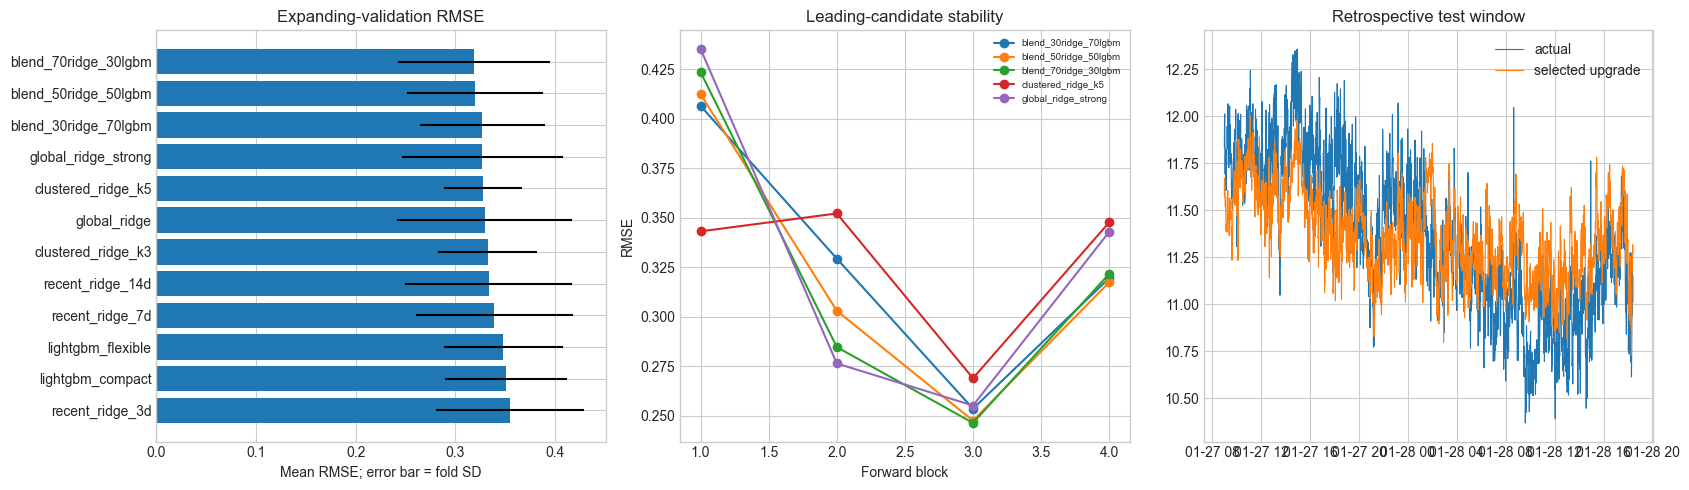

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_summary = candidate_summary.sort_values("mean_rmse", ascending=False)
axes[0].barh(plot_summary.candidate, plot_summary.mean_rmse, xerr=plot_summary.std_rmse)
axes[0].set_title("Expanding-validation RMSE")
axes[0].set_xlabel("Mean RMSE; error bar = fold SD")

for name, group in fold_results.groupby("candidate"):
    if name in candidate_summary.head(5).candidate.values:
        axes[1].plot(group.fold, group.rmse, marker="o", label=name)
axes[1].set(title="Leading-candidate stability", xlabel="Forward block", ylabel="RMSE")
axes[1].legend(fontsize=7)

sample = test_predictions.iloc[:2000]
axes[2].plot(sample.timestamp, sample.actual, label="actual", linewidth=0.8)
axes[2].plot(sample.timestamp, sample.prediction, label="selected upgrade", linewidth=0.8)
axes[2].set_title("Retrospective test window")
axes[2].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "upgrade_benchmark.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Export and readiness


### 8.1 Save evidence and selected model bundle


In [15]:
exports = {
    "dimensions": dimensions,
    "input_integrity": integrity,
    "fold_summary": fold_summary,
    "candidate_registry": candidate_registry,
    "fold_results": fold_results,
    "candidate_summary": candidate_summary,
    "selection": selection,
    "retrospective_comparison": comparison,
    "retrospective_test_predictions": test_predictions,
}
for name, frame in exports.items():
    frame.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

bundle = {
    "task": "target-free current-time virtual sensor upgrade",
    "selected_candidate": selected_candidate,
    "model": final_model,
    "imputer": final_imputer,
    "scaler": final_scaler,
    "features": features,
    "maximum_lookback": prep["MAX_LOOKBACK"],
    "selection_rule": selection.iloc[0].rule,
    "test_status": "retrospective; external month required",
}
joblib.dump(bundle, MODEL_DIR / "target_free_upgrade_candidate.joblib")
print("Exported upgrade evidence and candidate bundle.")


Exported upgrade evidence and candidate bundle.


### 8.2 Final readiness checks


In [16]:
readiness = pd.DataFrame([
    {"check": "target_and_target_history_absent", "status": bool(integrity.query("check in ['target_absent','target_derived_absent']").status.all())},
    {"check": "four_forward_validation_blocks", "status": len(folds) == 4},
    {"check": "no_shuffle", "status": True},
    {"check": "test_not_used_for_candidate_selection", "status": True},
    {"check": "selection_uses_mean_and_worst_fold", "status": True},
    {"check": "retrospective_test_labeled_honestly", "status": True},
    {"check": "selected_bundle_exists", "status": (MODEL_DIR / "target_free_upgrade_candidate.joblib").exists()},
    {"check": "all_exports_exist", "status": all((OUTPUT_DIR / f"{name}.csv").exists() for name in exports)},
])
assert readiness.status.all()
readiness.to_csv(OUTPUT_DIR / "readiness_checks.csv", index=False)
display(readiness)


,check,status
0,target_and_target_history_absent,True
1,four_forward_validation_blocks,True
2,no_shuffle,True
3,test_not_used_for_candidate_selection,True
4,selection_uses_mean_and_worst_fold,True
5,retrospective_test_labeled_honestly,True
6,selected_bundle_exists,True
7,all_exports_exist,True


## 9. Final decision


In [17]:
gain = float(comparison.query("candidate != 'Notebook05_frozen_blend'").rmse_change_vs_notebook05_pct.iloc[0])
print(f"Selected upgrade: {selected_candidate['name']}")
print(f"Mean expanding-validation RMSE: {selected_summary.mean_rmse:.4f}")
print(f"Worst expanding-validation RMSE: {selected_summary.worst_rmse:.4f}")
print(f"Retrospective test RMSE: {selected_test_metrics['rmse']:.4f}")
print(f"Retrospective RMSE change versus Notebook 05 blend: {gain:+.2f}%")
print("No production replacement is authorized until the candidate is tested on a genuinely later month.")


Selected upgrade: blend_50ridge_50lgbm
Mean expanding-validation RMSE: 0.3201
Worst expanding-validation RMSE: 0.4124
Retrospective test RMSE: 0.2879
Retrospective RMSE change versus Notebook 05 blend: +4.48%
No production replacement is authorized until the candidate is tested on a genuinely later month.


### Observations


- Replace the Notebook 05 bundle only if the upgrade is stable across forward blocks and improves on a new month.
- If recency weighting wins, gradual drift is likely important.
- If clustered experts win, operating-regime separation is likely important.
- If the blend remains best, linear and nonlinear errors remain complementary.
